# Lab: Logistic Regression for Customer Churn Predictions

---

## 1. Introduction

In this lab, we'll step into the shoes of a data scientist at a telecommunications company. The company is concerned about customers leaving for competitors and wants to identify which customers are at a high risk of "churning" (leaving).

* **Goal:** To build a logistic regression model that predicts the probability of a customer churning based on their demographic and service usage data.
* **Data:** A historical dataset of telecom customers, where each row represents a customer and includes details about their services and whether they churned.

---

## 2. Setup and Data Loading

We'll start by importing the necessary libraries. We'll use `pandas` for data handling, `numpy` for numerical operations, `matplotlib` and `seaborn` for plotting, and `sklearn` for our modeling and evaluation tools.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, jaccard_score, f1_score, log_loss, confusion_matrix

In [2]:
# Load the data from the URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
churn_df = pd.read_csv(url)

# Display a sample of the data
churn_df.sample(5)

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
63,6.0,24.0,2.0,28.0,1.0,5.0,0.0,1.0,0.0,4.40,...,0.0,0.0,1.0,1.0,0.0,1.482,2.197,3.332,3.0,1.0
180,56.0,53.0,23.0,100.0,5.0,14.0,1.0,1.0,0.0,14.15,...,0.0,1.0,0.0,0.0,1.0,2.650,3.240,4.605,2.0,0.0
188,25.0,38.0,19.0,56.0,1.0,19.0,1.0,1.0,1.0,10.55,...,0.0,0.0,0.0,1.0,0.0,2.356,3.240,4.025,3.0,0.0
166,70.0,36.0,8.0,50.0,1.0,15.0,0.0,1.0,0.0,20.55,...,0.0,0.0,0.0,0.0,0.0,3.023,3.240,3.912,2.0,0.0
95,11.0,63.0,9.0,41.0,3.0,3.0,1.0,0.0,0.0,4.15,...,0.0,1.0,0.0,0.0,1.0,1.423,3.240,3.714,1.0,1.0



---

## 3. Data Preprocessing and Exploration

Our first step is to prepare the data for the model. This involves selecting relevant features and ensuring they are in the correct format.

### 3.1 Feature Selection
For this model, we'll select a subset of numerical features that might influence a customer's decision to churn, such as their tenure with the company, age, income, and service usage.

In [3]:
# Select the features we'll use for the model
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]

# The 'churn' column is our target. Scikit-learn algorithms require the target to be numerical
# Let's convert it to an integer type (0 or 1)
churn_df['churn'] = churn_df['churn'].astype('int')

churn_df.head()

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0


### 3.2 Define Feature Matrix (X) and Target Vector (y)
Now we separate our data into the features (`X`) that will be used for prediction and the target (`y`) that we want to predict.

In [4]:
# X contains our independent variables (features)
X = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']].values

# y contains our dependent variable (the target)
y = churn_df['churn'].values

### 3.3 Create Train and Test Datasets

We must split our data before any further processing (like scaling). This ensures that our test set remains a truly "unseen" dataset for evaluating our model's performance.

In [5]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3.4. Standardize the Features
Our features are on different scales (e.g. `income` can be in the tens of thousands, while `age` is in double digits). We'll standardize them to have a mean of 0 and a standard deviation of 1.

**Best Practice:** We `fit` the scaler **only on the training data** to learn its parameters (mean and standard deviation). Then we use that *same* fitted scaler to `transform` both the training and test data. This prevents data leakage from the test set into our training process.

In [6]:
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)


---

## 4. Build and Train the Logistic Regression Model

Now we're ready to build our classifier. We'll use the `LogisticRegression` object from scikit-learn and train it on our scaled training data.

In [8]:
# 1. Create an instance of the LogisticRegression model
# C=0.01 is a regularization parameter. A smaller C means stronger regularization.
# solver='liblinear' is a good choice for smaller datasets.
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train_scaled, y_train)


---

## 5. Make Predictions and Evaluate the Model

With our trained model, we can now make predictions on the unseen test set and evaluate its performance.

### 5.1 Making Predictions

A logistic regression model can make two types of predictions:
1. `predict()`: Predicts the final class label (0 or 1)
2. `predict_proba()`: Predicts the probability for each class. The first column is the probability of class 0, and the second is the probability of class 1.

In [14]:
# Predict class labels
y_pred = LR.predict(X_test_scaled)

# Predict probabilities
y_pred_proba = LR.predict_proba(X_test_scaled)

### 5.2 Evaluating Performance

Let's use several common classification metrics to get a full picture of our model's performance.

* **Accuracy:** The percentage of correctly classified instances. Simple, but can be misleading if classes are imbalanced.
* **Jaccard Score:** The size of the intersection divided by the size of the union of the actual and predicted labels.
* **F1-Score:** The harmonic mean of precision and recall. It's a great metric for imbalanced datasets.
* **Log Loss:** The cost function the model tries to minimize. It measures the performance of a classifier that outputs a probability value. Lower is better.

In [12]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Jaccard Score: {jaccard_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred)}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba)}")

Accuracy: 0.80
Jaccard Score: 0.47
F1-Score: 0.6363636363636364
Log Loss: 0.5526697182071375


### 5.3 Confusion Matrix
A confusion matrix is an excellent way to visualize the performance of a classifier. Each row represents the actual class, while each column represents the predicted class.

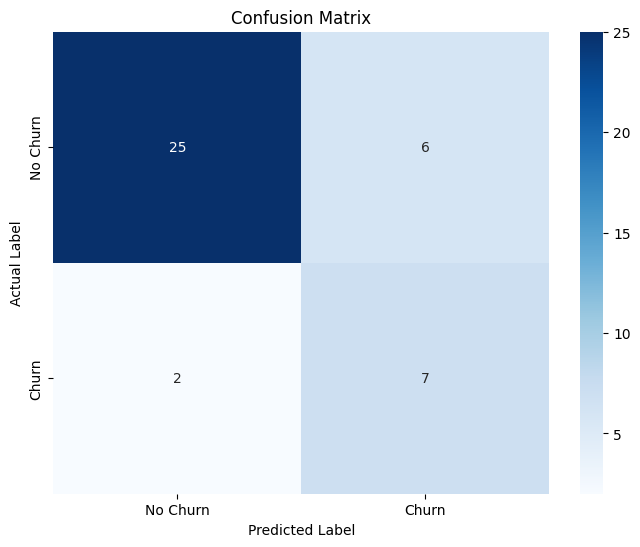

In [13]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

#### Interpretation of the Confusion Matrix
* **Top-Left (True-Negative):** Customers we correctly predicted would *not* churn.
* **Bottom-Right (True-Positive):** Customers we correctly predicted *would* churn.
* **Top-Right (False Positive):** Customers we incorrectly predicted would churn (but they stayed).
* **Bottom-Left (False Negative):** Customers we incorrectly predicted would not churn (but they left). **This is often the most costly error for the business.**

---

**Next:** [Classification](../03_building_supervised_learning_models/01_classification.md)